# laserion — Helium ionization examples

Open this notebook in **VS Code** or **Jupyter** and run the cells to view the
output of the two example decks (`He_focus/` and `He_intensity/`).

First run the decks (from a terminal), then run the cells below:

```
cd He_focus            && /rest_of_the_path/laserion/csrc/bin/laserion
cd He_intensity/low    && /rest_of_the_path/laserion/csrc/bin/laserion
cd He_intensity/mid    && /rest_of_the_path/laserion/csrc/bin/laserion
cd He_intensity/high   && /rest_of_the_path/laserion/csrc/bin/laserion
```

In [11]:
from pathlib import Path
import re
import numpy as np
import h5py
import matplotlib.pyplot as plt

# Locate the inputdeck directory whether this notebook runs from its own folder,
# the repo root, or csrc/.
_here = Path.cwd()
BASE = next((c for c in (_here, _here/"inputdeck", _here/"csrc"/"inputdeck", _here.parent)
             if (c/"He_focus").exists()), _here)
print("reading data under:", BASE)

def load(path):
    """Return (data, axes) where axes[i] = (min, max) of AXIS{i+1}."""
    with h5py.File(path, "r") as f:
        dset = next(f[k] for k in f if isinstance(f[k], h5py.Dataset) and k != "AXIS")
        data = np.asarray(dset[()])
        axes = [tuple(map(float, f["AXIS"][k][()])) for k in sorted(f["AXIS"])] if "AXIS" in f else []
    return data, axes

def read_grid(ms):
    """(ax1_min, dx1, axis_name) from a cache file, to map a z-index to z [um]."""
    caches = sorted((Path(ms)/"cache").glob("*.h5"))
    if not caches:
        return None
    with h5py.File(caches[0], "r") as f:
        a = f.attrs
        name = a.get("axis2", b"z")
        name = name.decode() if isinstance(name, bytes) else str(name)
        return float(a["ax1_min_um"]), float(a["dx1_um"]), name


reading data under: /Users/thales/Documents/laserion/csrc/inputdeck/examples


## Example 1 — a single focused pulse (`He_focus/`)

Left: the laser field vs time at three positions (before focus / at focus /
after focus). Right: the ionization fraction of each charge state along `z`.


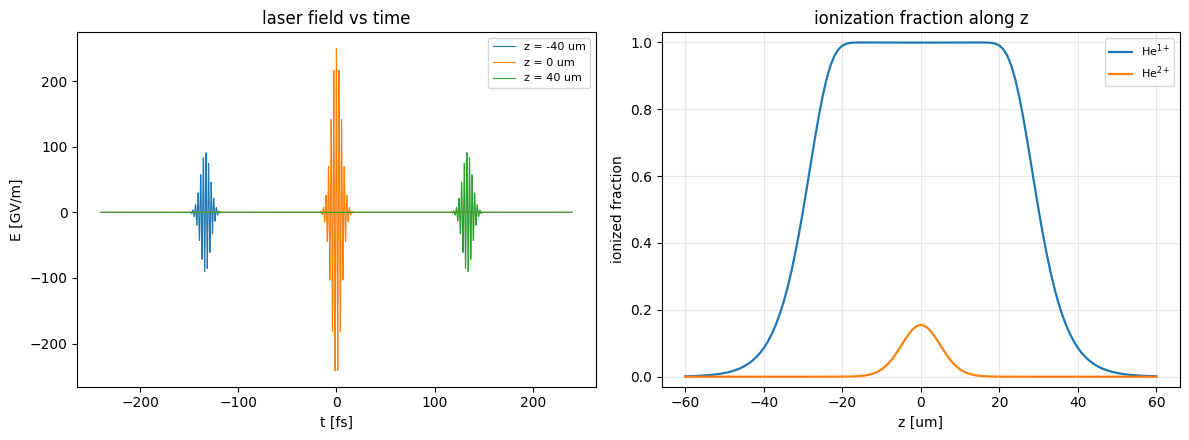

In [12]:
ms = BASE/"He_focus"/"MS"
grid = read_grid(ms)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 4.5))

# --- laser field snapshots, ordered before -> focus -> after ---
def zpos(p):
    m = re.search(r"_vs_t__([xyz])_(\d+)\.h5", str(p))
    return grid[0] + int(m.group(2))*grid[1] if (m and grid) else 0.0

for p in sorted((ms/"field").glob("*_vs_t__*.h5"), key=zpos):
    data, axes = load(p)
    t = np.linspace(axes[0][0], axes[0][1], data.shape[0])
    ax0.plot(t, data, lw=0.8, label=f"{grid[2]} = {zpos(p):.0f} um")
ax0.set(xlabel="t [fs]", ylabel="E [GV/m]", title="laser field vs time")
ax0.legend(fontsize=8)

# --- ionization fraction along z (Z00 is the mean charge, skip it) ---
for p in sorted((ms/"ioniz_frac").glob("ion_frac_Z*.h5")):
    Z = int(p.stem.split("Z")[-1])
    if Z == 0:
        continue
    frac, axes = load(p)
    z = np.linspace(axes[0][0], axes[0][1], frac.shape[0])
    ax1.plot(z, frac, lw=1.6, label=fr"He$^{{{Z}+}}$")
ax1.set(xlabel="z [um]", ylabel="ionized fraction",
        title="ionization fraction along z", ylim=(-0.03, 1.03))
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## Example 2 — scanning the intensity (`He_intensity/`)

Three runs at increasing peak field `E0`: the singly-ionized (He+) and
doubly-ionized (He2+) fractions along `z`.

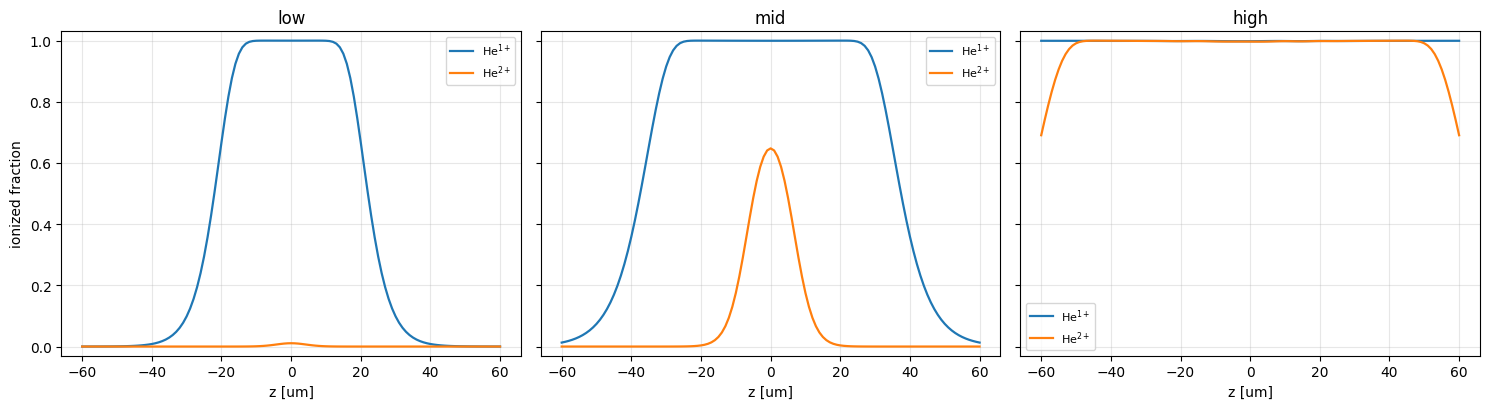

In [13]:
runs = ["low", "mid", "high"]
fig, axs = plt.subplots(1, len(runs), figsize=(5*len(runs), 4.2), sharey=True)

for ax, name in zip(axs, runs):
    ms = BASE/"He_intensity"/name/"MS"
    for p in sorted((ms/"ioniz_frac").glob("ion_frac_Z*.h5")):
        Z = int(p.stem.split("Z")[-1])
        if Z == 0:
            continue
        frac, axes = load(p)
        z = np.linspace(axes[0][0], axes[0][1], frac.shape[0])
        ax.plot(z, frac, lw=1.6, label=fr"He$^{{{Z}+}}$")
    ax.set(xlabel="z [um]", title=name, ylim=(-0.03, 1.03))
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
axs[0].set_ylabel("ionized fraction")
plt.tight_layout(); plt.show()
